In [7]:
import sys
sys.path.append('../')

import numpy as np
from matplotlib import pyplot as plt
import scqubits.settings as settings
settings.OVERLAP_THRESHOLD = 0.3
import utils_2Q_gate_zp as ut
import qutip as qt
import scqubits as scq
from scipy.ndimage import gaussian_filter
from IPython.display import display, Math

#### Drag in 4-level system

In [ ]:
drive_phi, drive_theta = False, True
truc1 = 300

In [ ]:
EL   = 0.04 # GHz
EJ   = 10 # Soft Zero Pi (Gyenis)
E_CJ = 20
E_C  = 0.04
phi_grid = scq.Grid1d(-6*np.pi, 6*np.pi, 100)
zero_pi = scq.ZeroPi(grid=phi_grid, EJ=EJ, EL=EL, ECJ=E_CJ, EC = E_C, dEJ=0.,
                        ng=0., flux=0., ncut=30, truncated_dim=truc1)
n_theta = zero_pi.matrixelement_table(operator='n_theta_operator', evals_count=truc1)
n_phi = zero_pi.matrixelement_table(operator='i_d_dphi_operator', evals_count=truc1)
n_Phi = 2*np.pi * qt.Qobj(n_phi)
n_Theta = 2*np.pi * qt.Qobj(n_theta)

In [ ]:
evals = zero_pi.eigenvals(evals_count=truc1)
H0 = 2*np.pi *qt.Qobj(np.diag(evals))

In [27]:
w_0_2 = (evals[2] - evals[0]) 
w_2_6 = (evals[6] - evals[2]) 
w_3_6 = (evals[6] - evals[3]) 
w_1_3 = (evals[3] - evals[1]) 
display(Math(r"\omega_{a}^{0-2} = %.3f \cdot 2\pi\ GHz = %.3f\ GHz" %(w_0_2, w_0_2*2*np.pi)  ))
display(Math(r"\omega_{a}^{2-6} = %.3f \cdot 2\pi\ GHz = %.3f\ GHz" %(w_2_6, w_2_6*2*np.pi)  ))
display(Math(r"\omega_{a}^{3-6} = %.3f \cdot 2\pi\ GHz = %.3f\ GHz" %(w_3_6, w_3_6*2*np.pi)  ))
display(Math(r"\omega_{a}^{1-3} = %.3f \cdot 2\pi\ GHz = %.3f\ GHz" %(w_1_3, w_1_3*2*np.pi)  ))
display(Math(r"n_{a}^{0-2} = %.3f, \ n_{a}^{2-6} = %.3f, \ n_{a}^{3-6} = %.3f, \ n_{a}^{1-3} = %.3f" 
             %(n_theta[0,2], n_theta[2,6], n_theta[3,6], n_theta[1,3])  ))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [32]:
thresh = 1e-3
w_trans = []
trans = []
trans_mat = []
for i in range(truc1):
    for j in np.arange(i+1, truc1):
        if np.abs(n_theta[i, j]) > thresh:
            f = np.round( np.abs(evals[i] - evals[j]), 8 )
            transition = str(i) + '-' + str(j)

            w_trans.append(f)
            trans.append(transition)
            trans_mat.append( np.round( np.abs(n_theta[i, j]) , 3))

# for i, _ in enumerate(trans):
#     print(i, trans[i], w_trans[i], trans_mat[i])

Text(0.5, 1.0, '$n_\\theta$ (Abdelhafez2020)')

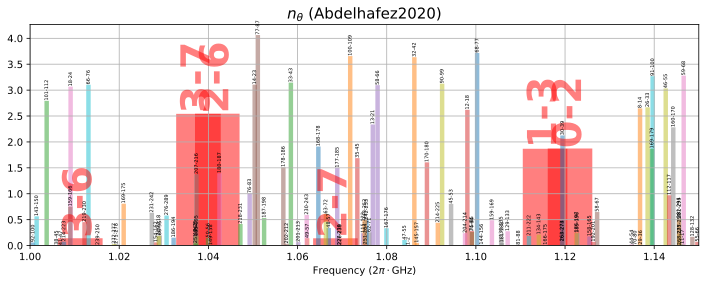

In [35]:
fig, ax = plt.subplots(figsize=(12,4))
y_shift = 0.005
state_overlap = ['0-10']
x_shift = [-0.3]
x_min, x_max = 1, 1.15
for i,_ in enumerate(w_trans):
    if x_min < w_trans[i] < x_max:# and trans_mat[i] < 2:
        if trans[i] in ['0-2', '2-6', '3-6', '1-3', '2-7', '3-7',]:
            plt.bar(w_trans[i], trans_mat[i], width=0.01, color='red', alpha=0.5)
            plt.text(w_trans[i], trans_mat[i] +y_shift, trans[i], 
                     ha="center", va="bottom", rotation=90, fontsize=40, fontweight='bold', color='red', alpha=0.5)
        else:
            plt.bar(w_trans[i], trans_mat[i], width=0.001, alpha=0.5)
            plt.text(w_trans[i], trans_mat[i] +y_shift, trans[i], ha="center", va="bottom", rotation=90, fontsize=5)

# plt.ylim(0,0.17)
plt.xlim(x_min,x_max)
plt.xlabel(r'Frequency (2$\pi\cdot$GHz)')
plt.grid()
# plt.xticks(np.arange(x_min, x_max, 2))  # Set custom x-axis ticks
# plt.ylabel('Max population during X gate')
ax.set_title(r'$n_\theta$ (Abdelhafez2020)', fontsize=15)
# plt.title(r'$n_\phi:\psi_0=$'+f'{state_good}', fontsize=15)

#### Matrix element table

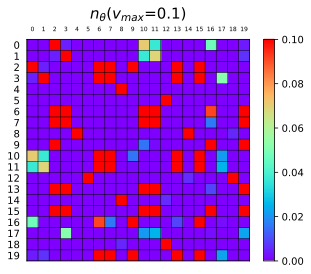

In [ ]:
vmax = 0.1
truc_mat = 20
fig, ax = plt.subplots(figsize=(5,4))
font_size = 15
plt.imshow(np.abs(n_theta[:truc_mat,:truc_mat]), vmax=vmax, aspect="auto",cmap='rainbow')
ax.set_title(r'$n_\theta$ (Abdelhafez2020)', fontsize=15)
plt.title(r'$n_{\theta}$($v_{max}$='+f'{vmax})' , pad=8,fontsize=font_size)
ax.set_xticks(np.arange(0, truc_mat, 1), np.arange(0, truc_mat, 1), fontsize=6)
ax.set_yticks(np.arange(0, truc_mat, 1), np.arange(0, truc_mat, 1))
ax.xaxis.tick_top()
ax.set_xticks(np.arange(-.5, truc_mat, 1), minor=True)
ax.set_yticks(np.arange(-.5, truc_mat, 1), minor=True)
ax.grid(which='minor', color='k', linestyle='-', linewidth=0.5)
ax.tick_params(which='both', left=False, top=False)
plt.colorbar()
# plt.savefig('image/n_theta.png',dpi=150, bbox_inches='tight')